In [ ]:
from skimage.io import imread
from skimage import img_as_float
from skimage.color import rgb2gray
#from skimage.util import pad
from skimage.util import random_noise
import numpy as np
from scipy.stats import norm
from scipy import signal
import matplotlib.pyplot as plt

Helper Functions

In [ ]:
def plot_image(img,figsize=(5,5)):
    plt.figure(figsize=figsize)
    if len(img.shape)==2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)
    plt.axis("off")
    plt.show()
    print("Image shape: ", img.shape)

def plot_kernel(kernel, cmap="Reds"):
    plt.imshow(kernel, interpolation='none', cmap="Reds")
    plt.colorbar()
    plt.show()
    print("Kernel shape: ", kernel.shape)

"""
def gaussian_kernel(width=1, size=10):
    gaussian1dkernel = signal.gaussian(size, width).reshape(size, 1)
    kernel = np.outer(gaussian1dkernel, gaussian1dkernel)
    return kernel/np.sum(kernel)

"""

def gaussian_kernel(sigma=1, size=10):

    # Create a 1D Gaussian kernel
    x = np.linspace(-size // 2, size // 2, size)
    gaussian_1d = norm.pdf(x, scale=sigma)
    gaussian_1d = gaussian_1d / np.sum(gaussian_1d)  # Normalize

    # Create 2D Gaussian kernel using outer product
    gaussian_2d = np.outer(gaussian_1d, gaussian_1d)

    return gaussian_2d


def box_kernel(size=5):
    return np.ones((size, size))/size**2

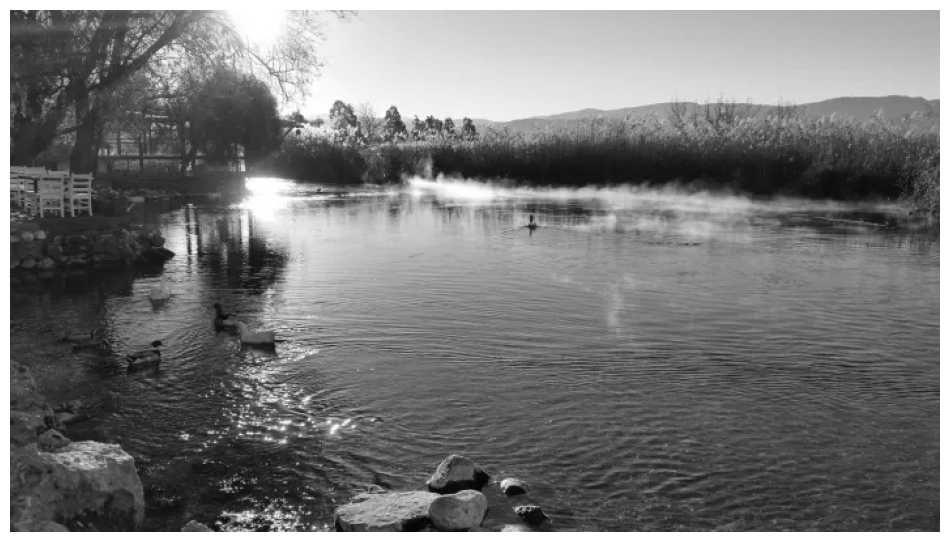

Image shape:  (400, 712)


In [ ]:
## IMPORT & PLOT IMAGE

img = rgb2gray(imread("/content/Riverside.webp"))
plot_image(img, (12,12))

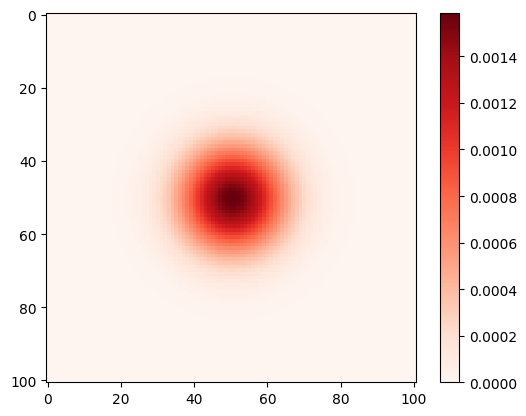

Kernel shape:  (101, 101)


In [ ]:
## DEFINE & PLOT KERNEL

# kernel shape (k, k). k should be odd
k = 101

# spread for gaussian, spread > 1
spread = k/10 # or define manually

# calculate pad width from (k-1) / 2
pad_width = int((k-1)/2)

# define either a box kernel or a gaussian kernel by calling the pre defined functions
kernel = gaussian_kernel(spread, size=k)
#kernel = box_kernel(size=k)
plot_kernel(kernel)

In [ ]:
# filter img with kernel via correlation
img_filtered = signal.correlate(img, kernel, mode='same', method='auto') # experiment with method="direct"

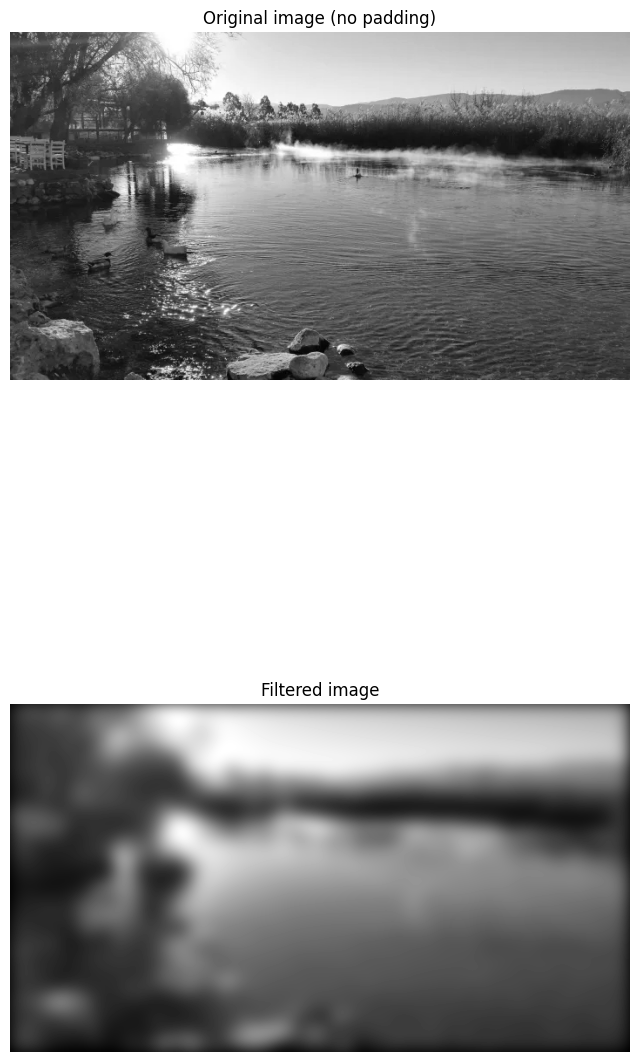

In [ ]:
#Multiple plots using pyplot
fig = plt.figure(figsize=(8, 16))

ax1 = fig.add_subplot(2,1,1)
ax1.imshow(img, cmap="gray")
ax1.title.set_text('Original image (no padding)')
ax1.axis("off")

ax2 = fig.add_subplot(2,1,2)
ax2.imshow(img_filtered, cmap="gray")
ax2.title.set_text('Filtered image')
ax2.axis("off")

plt.show()